# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [114]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf
import random
import matplotlib.pyplot as plt
import wandb
from wandb.integration.keras import WandbMetricsLogger
import os

## Setup for loading weights or Not

In [185]:
LOAD_WEIGHTS = False

In [172]:


WANDB_USER = ""  # insert your wandb username here
WANDB_PROJECT = "DL_JIGSAW"  # insert your wandb project name here
WANDB_RUN_NAME = "patches_to_image_spec"  # insert a descriptive name for this run here


We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [119]:
def download_and_load_stl10():
    # Download and extract the dataset
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )

    # Get the base directory (typically ~/.keras/datasets/)
    base_dir = os.path.dirname(path)

    # Based on your error, we navigate to the extracted subfolder
    data_dir = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, 'rb') as f:
        # STL-10 unlabeled set contains 100,000 images
        # Data is stored as uint8, (N, C, H, W)
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))

        # Transpose from (N, C, H, W) to (N, H, W, C) for standard image processing
        images = np.transpose(images, (0, 3, 2, 1))

    return images

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        # self.images = images.astype("float32") / 255.0  # Normalize on the fly or pre-normalize
        self.images = images # Normalize on the fly or pre-normalize
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        # X: (Batch, 9 patches, 28, 28, 3)
        # y: (Batch, 9) representing the original position index
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx].astype("float32") / 255.0
            Y[i] = full_img
            patches = []

            # Extract 9 patches in a 3x3 grid
            for r in range(3):
                for c in range(3):
                    # Define grid coordinates
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]

                    # Center Crop to avoid edge-matching shortcuts (we could go random crop)
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            # Create a permutation (0-8)
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [197]:
# Trigger the download and loading
images = download_and_load_stl10()
print(f"Successfully loaded {images.shape[0]} images.")

Loading data from: /Users/mamads/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 100000 images.


In [198]:
print(images.shape)


(100000, 96, 96, 3)


In [199]:
# define a dictionary to have configs for the model and training
cfg ={
    "batch_size": 64,
    "lr": 1e-3,
    "epochs": 10,
    "lr_factor": 0.5,
    "min_lr": 1e-6,
    "train_split": 0.8,
    "val_split": 0.1,
    "test_split": 0.1,
    "data_size": 100000,  # Use a subset for faster experimentation
    
}
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
images = images[:cfg["data_size"]]

In [200]:
train_images = images[:int(cfg["train_split"] * len(images))]
val_images = images[int(cfg["train_split"] * len(images)):int((cfg["train_split"] + cfg["val_split"]) * len(images))]
test_images = images[int((cfg["train_split"] + cfg["val_split"]) * len(images)):int((cfg["train_split"] + cfg["val_split"] + cfg["test_split"]) * len(images))]
print("Train size is", len(train_images))
print("Val size is", len(val_images))
print("Test size is", len(test_images))

Train size is 80000
Val size is 10000
Test size is 10000


In [201]:
train_generator = PatchGenerator(train_images, batch_size=cfg["batch_size"])
val_generator = PatchGenerator(val_images, batch_size=cfg["batch_size"])
test_generator = PatchGenerator(test_images, batch_size=cfg["batch_size"])

Let us inspect the dataset.

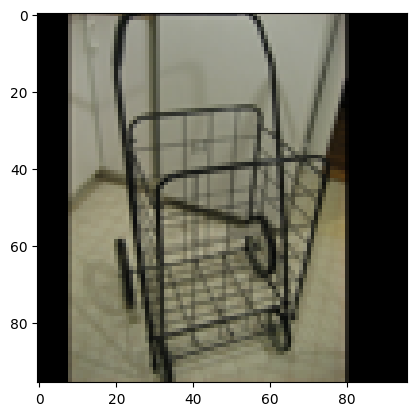

In [202]:
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [203]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    return canvas


In [204]:
a,b = test_generator.__getitem__(1)

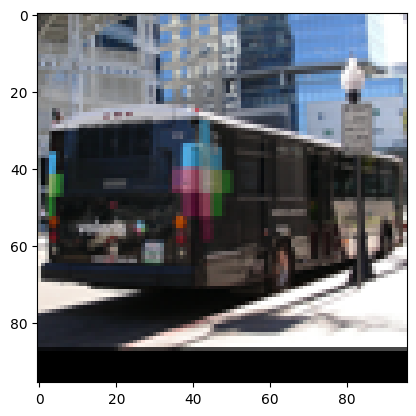

In [205]:
plt.imshow(b[4])

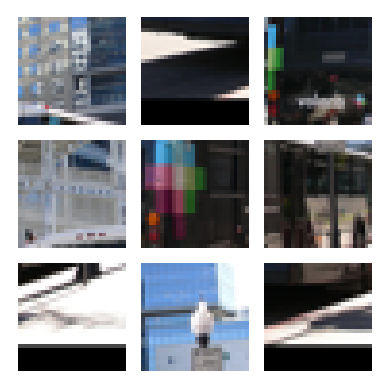

In [206]:
plt.imshow(plot_puzzle(a[4], ordering=None))
plt.axis('off')
plt.show()

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [164]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [165]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.17738684, shape=(), dtype=float32)
std: tf.Tensor(0.0, shape=(), dtype=float32)


## Define the model layers

### Assembly layer

In [167]:
@tf.keras.utils.register_keras_serializable()
class DifferentiableAssemblyLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.slot_embeddings = self.add_weight(
            shape=(9, 256),
            initializer="random_normal",
            trainable=True,
            name="slot_embeddings"
        )
        
    def call(self, inputs):
        patches, patch_features = inputs 
        B = tf.shape(patches)[0]
        
        logits = tf.einsum('sc,bpc->bsp', self.slot_embeddings, patch_features)
        P = tf.nn.softmax(logits, axis=-1) 
        
        soft_patches = tf.einsum('bsp,bphwi->bshwi', P, patches) 
        padded_patches = tf.pad(soft_patches, [[0,0], [0,0], [2,2], [2,2], [0,0]])
        
        grid_img = tf.reshape(padded_patches, (B, 3, 3, 32, 32, 3))
        grid_img = tf.transpose(grid_img, [0, 1, 3, 2, 4, 5])
        assembled_img = tf.reshape(grid_img, (B, 96, 96, 3))
        
        mask_patch = tf.ones((28, 28, 1))
        padded_mask = tf.pad(mask_patch, [[2,2], [2,2], [0,0]])
        padded_mask = tf.broadcast_to(padded_mask, [B, 9, 32, 32, 1])
        grid_mask = tf.reshape(padded_mask, (B, 3, 3, 32, 32, 1))
        grid_mask = tf.transpose(grid_mask, [0, 1, 3, 2, 4, 5])
        assembled_mask = tf.reshape(grid_mask, (B, 96, 96, 1))
        
        assembled_concat = tf.concat([assembled_img, assembled_mask], axis=-1)
        return assembled_concat


### Custom logger

In [168]:
class CustomEvaluationLogger(keras.callbacks.Callback):
    def __init__(self, test_generator):
        super().__init__()
        self.test_generator = test_generator
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_mae = logs.get('loss')
        val_mae = logs.get('val_loss')
        
        print(f"\nEvaluating Test Set at the end of Epoch {epoch + 1}...")
        test_mae = self.model.evaluate(self.test_generator, verbose=0)
        
        print(f"Epoch {epoch + 1} -> Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | Test MAE: {test_mae:.4f}")
        
        wandb.log({
            "Train Set MAE": train_mae,
            "Validation Set MAE": val_mae,
            "Test Set MAE": test_mae,
        })

### Base model

In [ ]:
class JigsawPuzzleModel:
    def __init__(self):
        self.model = self._build_model()
        
    def _build_model(self):
        inputs = layers.Input(shape=(9, 28, 28, 3))
        
        # === 1. Patch Encoder (CNN) ===
        encoder_input = layers.Input(shape=(28, 28, 3))
        x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(encoder_input)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(256, 3, strides=2, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling2D()(x)
        patch_encoder = models.Model(encoder_input, x, name="patch_encoder")
        
        encoded_patches = layers.TimeDistributed(patch_encoder)(inputs)
        
        # === 2. Transformer Context (Increased parameters: 4 Layers, 640 FFN) ===
        x = encoded_patches
        for _ in range(4):
            attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
            x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
            ffn_out = layers.Dense(640, activation='relu')(x)
            ffn_out = layers.Dense(256)(ffn_out)
            x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)
            
        patch_features = x 
        
        # === 3. Differentiable Assembly ===
        assembled_concat = DifferentiableAssemblyLayer()([inputs, patch_features])
        
        # === 4. U-Net Refinement (Increased parameters: 384 Bottleneck) ===
        c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(assembled_concat)
        c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
        p1 = layers.MaxPooling2D()(c1) 
        
        c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
        c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
        p2 = layers.MaxPooling2D()(c2) 
        
        c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
        c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
        p3 = layers.MaxPooling2D()(c3) 
        
        # Bottleneck increased to 384 filters
        c4 = layers.Conv2D(384, 3, activation='relu', padding='same')(p3)
        c4 = layers.Conv2D(384, 3, activation='relu', padding='same')(c4)
        
        u5 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c4) 
        u5 = layers.Concatenate()([u5, c3])
        c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(u5)
        c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(c5)
        
        u6 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c5) 
        u6 = layers.Concatenate()([u6, c2])
        c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(u6)
        c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(c6)
        
        u7 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c6) 
        u7 = layers.Concatenate()([u7, c1])
        c7 = layers.Conv2D(32, 3, activation='relu', padding='same')(u7)
        c7 = layers.Conv2D(32, 3, activation='relu', padding='same')(c7)
        
        outputs = layers.Conv2D(3, 1, activation='sigmoid', name="output_image")(c7)
        
        return models.Model(inputs=inputs, outputs=outputs, name="jigsaw_solver")
    def print_parameter_count(self):
        params = self.model.count_params() / 1_000_000
        print(f"Total Parameters: {params:.2f} M")
    
    def load_weights(self,):
        if os.path.exists("jigsaw_model.weights.h5"):
            print("Loading weights from checkpoint...")
            self.model.load_weights("jigsaw_model.weights.h5")
        else:
            print("No checkpoint found. Starting training from scratch.")
        
    def fit(self, train_generator, val_generator, test_generator, epochs=20):
        

        # Compile Model
        self.model.compile(optimizer=keras.optimizers.Adam(cfg["lr"]), loss='mae')
        
        # Init W&B
        os.environ["WANDB_DISABLE_SYSTEM_METRICS"] = "true"
        wandb.init(project=WANDB_PROJECT, name=WANDB_RUN_NAME,config=cfg)
        os.environ["WANDB_DISABLE_SYSTEM_METRICS"] = "true"
        
        
        # Callbacks
        callbacks = [
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=cfg["lr_factor"], patience=2, min_lr=cfg["min_lr"], verbose=1),
            CustomEvaluationLogger(test_generator),
            keras.callbacks.ModelCheckpoint(
                filepath="jigsaw_model.weights.h5",
                monitor="val_loss",
                save_best_only=True,
                save_weights_only=True,
                mode="min",
                verbose=1
            )
        ]
        
        
        self.model.fit(
            train_generator, 
            validation_data=val_generator, 
            epochs=epochs, 
            callbacks=callbacks
        )
        
        
        wandb.finish()
        

## Train

In [ ]:
model = JigsawPuzzleModel()
model.print_parameter_count()
if LOAD_WEIGHTS:
    print("Loading weights from checkpoint...")
    model.load_weights()
model.fit(train_generator, val_generator, test_generator, epochs=cfg["epochs"])

Total Parameters: 5.64 M


Test Set MAE,█▆▄▂▁
Train Set MAE,█▅▃▂▁
Validation Set MAE,█▆▄▁▁
Test Set MAE,0.15171
Train Set MAE,0.15383
Validation Set MAE,0.15047


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pydantic/main.py:314: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - loss: 0.1623
Evaluating Test Set at the end of Epoch 1...
Epoch 1 -> Train MAE: 0.1565 | Val MAE: 0.1526 | Test MAE: 0.1519

Epoch 1: val_loss improved from inf to 0.15262, saving model to jigsaw_model.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 533s 407ms/step - loss: 0.1623 - val_loss: 0.1526 - learning_rate: 0.0010
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - loss: 0.1491
Evaluating Test Set at the end of Epoch 2...


In [177]:
# Evaluation Metric computation
def evaluate_and_get_metrics(model, generator):
    mae_metric = tf.keras.metrics.MeanAbsoluteError()
    mae_values = []
    
    for i in range(len(generator)):
        x_batch, y_true_img = generator.__getitem__(i)
        # Predict
        y_pred_img = model(x_batch, training=False)
        
        # calculate mae per batch
        mae_metric.update_state(y_true_img, y_pred_img)
        batch_mae = mae_metric.result().numpy()
        mae_values.append(batch_mae)

    mae_mean = tf.reduce_mean(mae_values)
    std = tf.math.reduce_std(mae_values)
    return mae_mean.numpy(), std.numpy()

In [179]:
mae_mean, std = evaluate_and_get_metrics(model.model, test_generator)
print(f"Test MAE over all test batches: {mae_mean}")
print(f"Test std: {std}")

Test MAE over all test batches: 0.22621184587478638
Test std: 0.0


### Visualize results

In [180]:

def visualize_random_predictions(model, generator, num_samples=3):

    
    # Pick a random batch
    batch_idx = random.randint(0, len(generator) - 1)
    X_batch, Y_batch = generator[batch_idx]
    
    # Predict
    preds = model.predict(X_batch, verbose=0)
    
    # Pick random indices within the batch
    actual_batch_size = len(X_batch)
    sample_indices = random.sample(range(actual_batch_size), min(num_samples, actual_batch_size))
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    if num_samples == 1:
        axes = [axes]
        
    for i, idx in enumerate(sample_indices):
        orig_img = Y_batch[idx]
        pred_img = preds[idx]
        scrambled_patches = X_batch[idx] # Shape: (9, 28, 28, 3)
        
        # 1. Assemble scrambled patches into a tight 84x84 grid for visualization
        scrambled_grid = plot_puzzle(scrambled_patches, ordering=None)
        
            
        # 4. Absolute Difference
        abs_diff = np.abs(orig_img - pred_img)
        mae = np.mean(abs_diff)
        
        # Column 0: Scrambled Input
        axes[i][0].imshow(scrambled_grid)
        axes[i][0].set_title("Scrambled Input")
        axes[i][0].axis('off')
        
        # Column 1: Original Image
        axes[i][1].imshow(orig_img)
        axes[i][1].set_title("Original Image")
        axes[i][1].axis('off')
        
        # Column 2: Reconstructed
        axes[i][2].imshow(pred_img)
        axes[i][2].set_title(f"Reconstructed (MAE: {mae:.4f})")
        axes[i][2].axis('off')
        
        # Column 3: Absolute Error
        axes[i][3].imshow(np.clip(abs_diff, 0, 1))
        axes[i][3].set_title("Absolute Error")
        axes[i][3].axis('off')
        
    plt.tight_layout()
    plt.show()

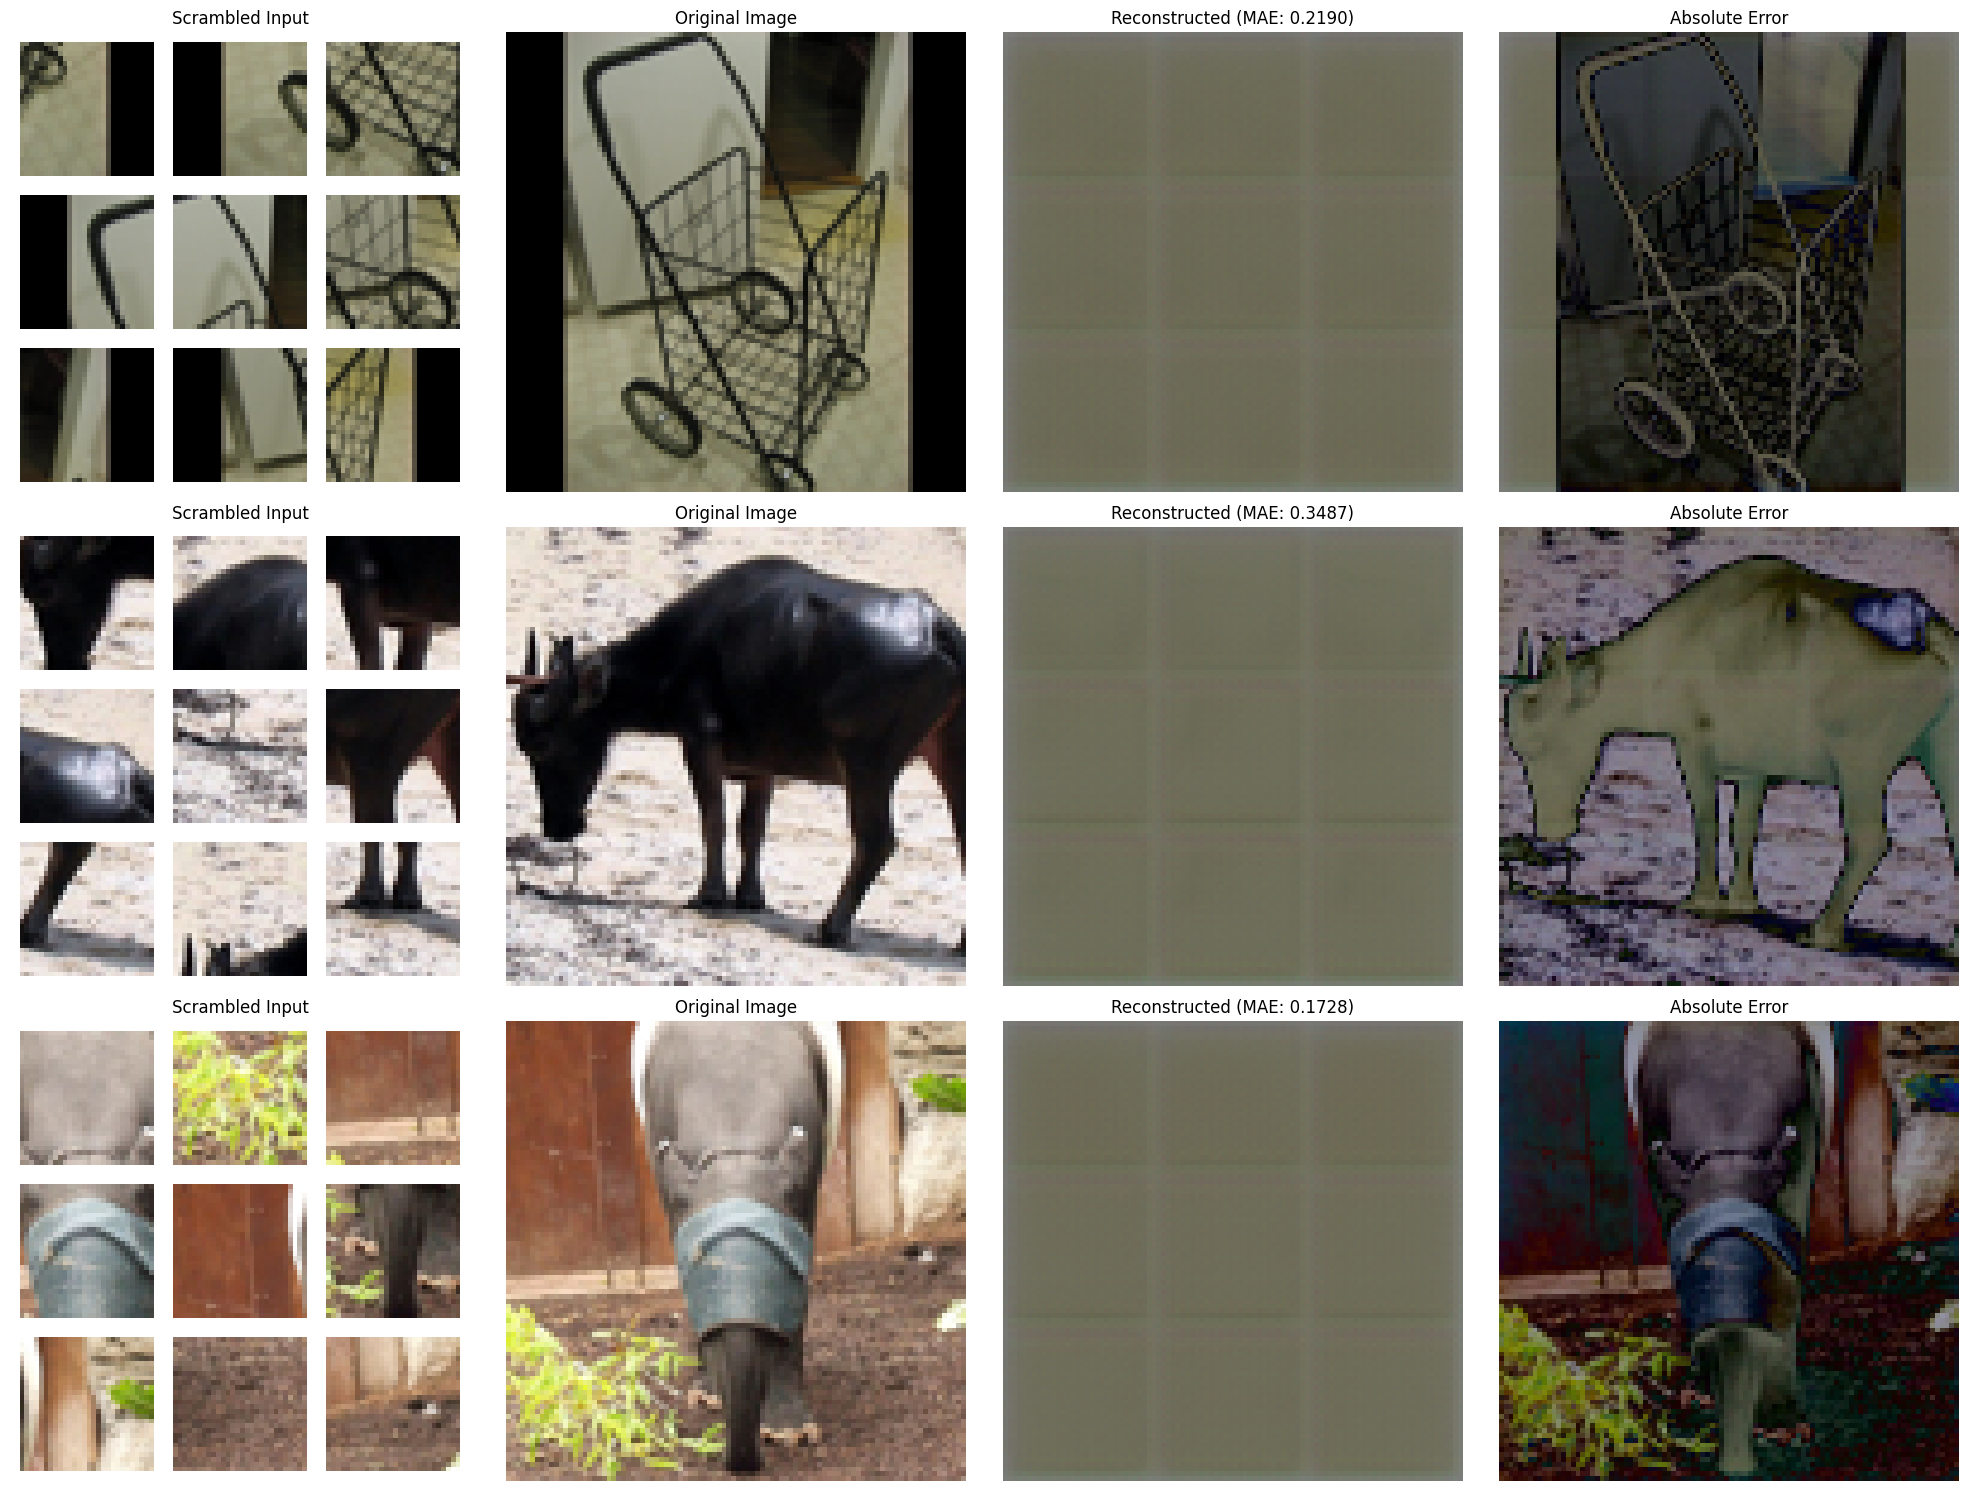

In [187]:
visualize_random_predictions(model.model, test_generator, num_samples=3)

# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.



